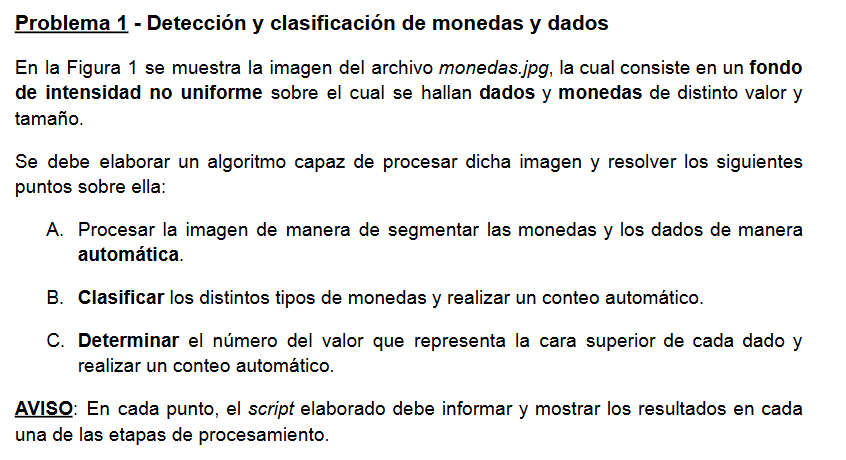

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import math

# PARTE A

In [13]:
img = cv2.imread('img/monedas.jpg')
copia_img = img.copy()



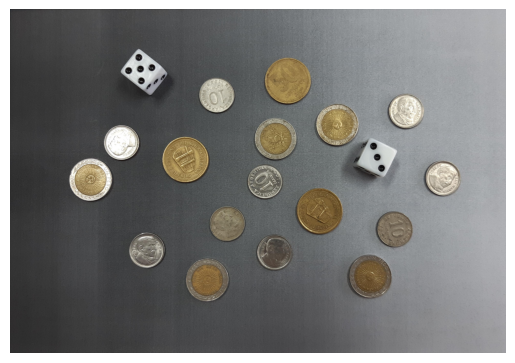

In [3]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [9]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

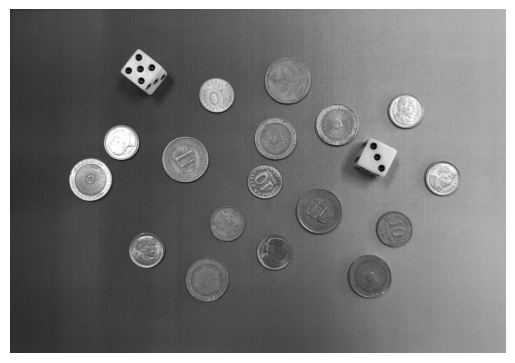

In [ ]:
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.show()

In [10]:
# filtro gaussiano
img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

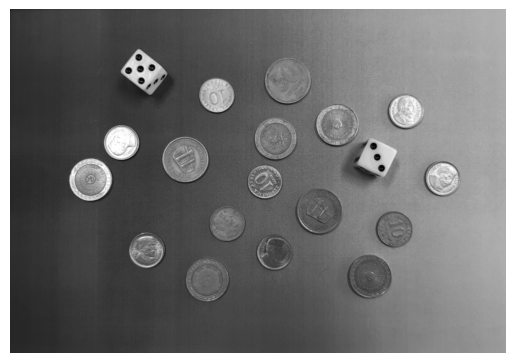

In [ ]:
plt.imshow(img_gris_blur, cmap='gray')
plt.axis('off')
plt.show()

umbralado de la practica pdi_u3_segmentacion.py

con  cv2.threshold()

https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

100.0
uint8
[  0 255]


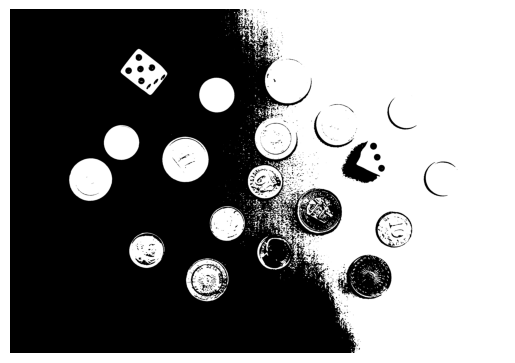

In [ ]:
th_out, img_umbralado = cv2.threshold(img_gris_blur, thresh=100, maxval=255, type=cv2.THRESH_BINARY)
print(th_out)
print(img_umbralado.dtype)
print(np.unique(img_umbralado))
plt.imshow(img_umbralado, cmap='gray')
plt.axis('off')
plt.show()

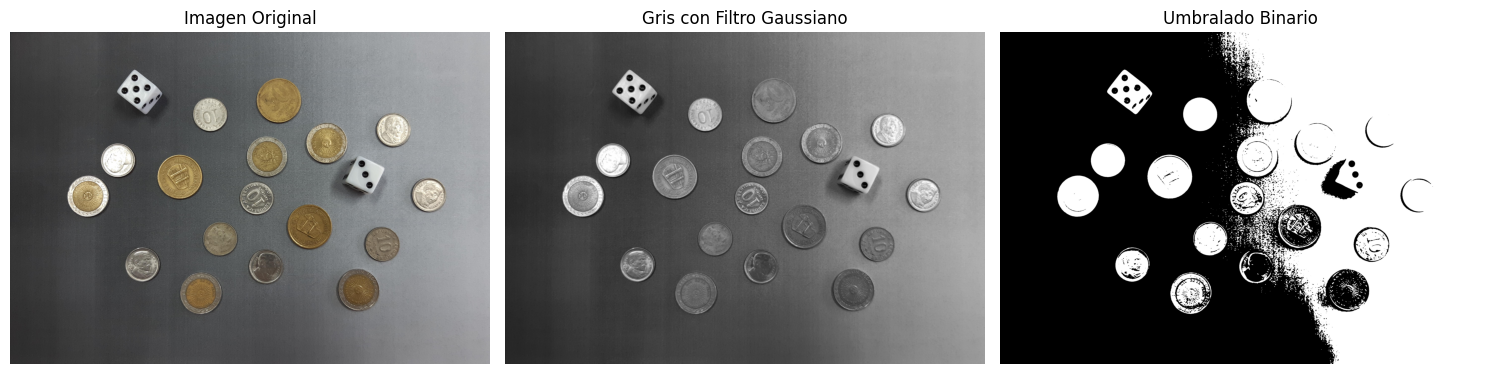

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Gris con Filtro Gaussiano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado, cmap='gray')
plt.title('Umbralado Binario')
plt.axis('off')

plt.tight_layout()
plt.show()


 cv2.adaptiveThreshold(

   imagen_fuente (grises),

   valor_maximo (255, blanco),

   metodo_adaptativo (cv2.ADAPTIVE_THRESH_GAUSSIAN_C -> mejor para iluminación variable),

   tipo_umbral (cv2.THRESH_BINARY_INV -> Invertido, queremos objetos blancos),

   tamano_bloque (ej. 31x31 píxeles, debe ser impar),
   
   C (constante a restar de la media, ajusta la sensibilidad)
 )

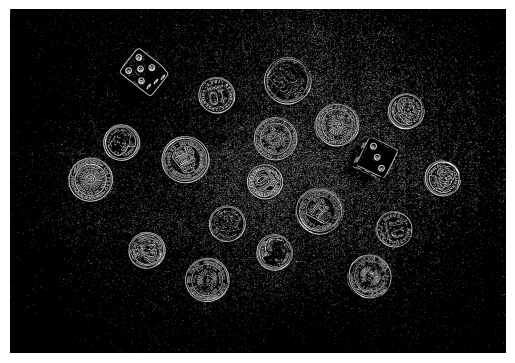

In [ ]:
# hay que hacer umbralado local (vecinos)
img_umbralado_oscuro = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # objetos oscuros
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.axis('off')
plt.show()

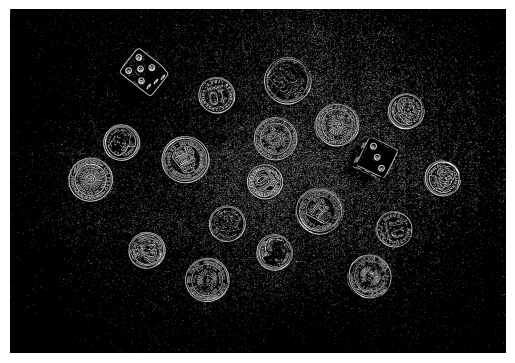

In [ ]:
# hay que hacer umbralado local (vecinos)
img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

celda_invertida = 255 - img_umbralado_blancos

plt.imshow(celda_invertida, cmap='gray')
plt.axis('off')
plt.show()

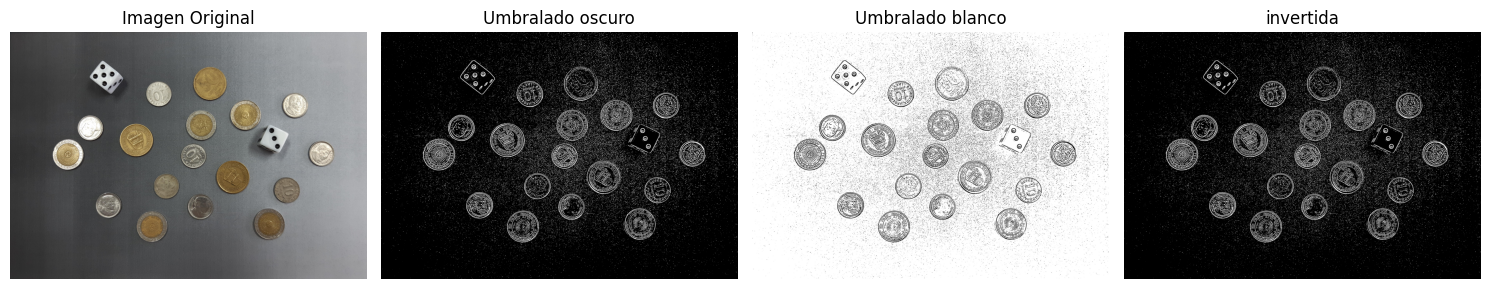

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.title('Umbralado oscuro')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Umbralado blanco')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(celda_invertida, cmap='gray')
plt.title('invertida')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# componentes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    celda_invertida,
    connectivity=8,
    ltype=cv2.CV_32S
)
print(num_labels, labels, stats, centroids)
img_umbralado_blancos.shape

46634 [[0 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] [[      0       0    3871    2681 9567848]
 [      0       0       3       8      18]
 [    211       0       3       3       6]
 ...
 [   2352    2678       3       3       4]
 [   2828    2679       3       2       3]
 [   3540    2678       4       3       6]] [[1.92350460e+03 1.34702231e+03]
 [7.77777778e-01 3.44444444e+00]
 [2.12166667e+02 8.33333333e-01]
 ...
 [2.35300000e+03 2.67875000e+03]
 [2.82900000e+03 2.67933333e+03]
 [3.54150000e+03 2.67916667e+03]]


(2681, 3871)

In [ ]:
def encontrar_figuras(imagen, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, k, umbral_global):

    objetos_contados = 0 

    conteo_areas={}

    recortes_para_ensamblar = []

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray_blur = cv2.GaussianBlur(img_gris, (3, 3), 1)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

    # Top-Hat 
    # Lo usamos para encontrar todos los objetos brillantes en la imagen que son más pequeños que el kernel.
    tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

    # Black-Hat
    # Lo usamos para encontrar todos los objetos oscuros en la imagen que son más pequeños que el kernel.
    blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

    # combinar mascaras
    # Obtiene una única imagen donde el fondo no uniforme ha sido completamente eliminado (es negro) y todos los objetos (brillantes y oscuros) están resaltados.
    mask = cv2.add(tophat, blackhat)

    ret2, mask_thresh = cv2.threshold(mask, umbral_global, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
) 

    """img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )"""

    #celda_invertida = 255 - img_umbralado_blancos

    """(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    celda_invertida,
    connectivity=8,
    ltype=cv2.CV_32S
)"""

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:

            #area_agrupada = int((area // 100.0)* 100) 
            area_agrupada = int(math.ceil(area / 100.0)) * 100

            if area_agrupada in conteo_areas:
                conteo_areas[area_agrupada] += 1
            
            else:
                conteo_areas[area_agrupada] = 1
    
            objetos_contados += 1 

            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            
            cv2.rectangle(img_gris, (x, y), (x + w, y + h), (0, 255, 0), 2)
            (cX, cY) = centroids[i] 
            cv2.putText(img_gris, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

            """cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 2)

            (cX, cY) = centroids[i]
            cv2.putText(imagen, str(objetos_contados), (int(cX) - 10, int(cY)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
            objeto_recortado = imagen[y:y + h, x:x + w]
            
            recortes_para_ensamblar.append(objeto_recortado)
            
            nombre_ventana = f"Objeto {objetos_contados} (Area: {area_agrupada})"
            cv2.imshow(nombre_ventana, objeto_recortado)"""


    return  objetos_contados, conteo_areas #, imagen_ensamblada_recortes
  
encontrar_figuras(copia_img, 2550, 4800, 50, 75)



(1, {3900: 1})

In [ ]:
def encontrar_objetos(img, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, umbral_global, kernel):
    
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
    img_tophat = cv2.morphologyEx(img_gris, cv2.MORPH_TOPHAT, kernel_tophat)
    img_gris_blur = cv2.GaussianBlur(img_tophat, (3, 3), 0)
    
    ret, img_umbralado = cv2.threshold(img_gris_blur, umbral_global, 255, cv2.THRESH_BINARY)
    
    kernel_cierre = np.ones((5, 5), np.uint8) 
    celda_cerrada = cv2.morphologyEx(img_umbralado, cv2.MORPH_CLOSE, kernel_cierre)
    kernel_apertura = np.ones((3, 3), np.uint8)
    celda_limpia = cv2.morphologyEx(celda_cerrada, cv2.MORPH_OPEN, kernel_apertura)
    
    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(celda_limpia, connectivity=8, ltype=cv2.CV_32S)
    
    objetos_validos = []
    
    # bucle componentes y  filtro de área
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:
            
            objetos_validos.append({'id': i,'area': area,'stats': stats[i],'centroid': centroids[i]})
   
    # ordena los objetos válidos por área de mayor a menor
    objetos_validos.sort(key=lambda x: x['area'], reverse=True)
      
    num_dados = 2 
    
    objetos_contados = 0
    contador_areas = {}
    contador_tipos = {"Moneda": 0, "Dado": 0, "Otros": 0} 
    recortes_para_ensamblar = []
    img_resultado = img.copy()
    
    for idx, objeto in enumerate(objetos_validos):   
        
        if idx < num_dados:
            tipo_objeto = "Dado"
            color_rectangulo = (0, 0, 255) 
            contador_tipos["Dado"] += 1
        else:
            tipo_objeto = "Moneda" 
            color_rectangulo = (0, 255, 0)
            contador_tipos["Moneda"] += 1
    
        x = objeto['stats'][cv2.CC_STAT_LEFT]
        y = objeto['stats'][cv2.CC_STAT_TOP]
        w = objeto['stats'][cv2.CC_STAT_WIDTH]
        h = objeto['stats'][cv2.CC_STAT_HEIGHT]
        area = objeto['area']
        
        objetos_contados += 1 

        area_agrupada = int(math.ceil(area / 100.0)) * 100
        contador_areas[area_agrupada] = contador_areas.get(area_agrupada, 0) + 1
        
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), color_rectangulo, 2)
        (cX, cY) = objeto['centroid']
        etiqueta = f"{objetos_contados}:{tipo_objeto[0]}"
        cv2.putText(img_resultado, etiqueta,(int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        objeto_recortado = img[y:y + h, x:x + w]
        recortes_para_ensamblar.append(objeto_recortado)
  
    print(" Segmentación con Top-Hat y clausura ")
    print(f"Objetos detectados válidos: {objetos_contados}")
    print(f"Contador por tipo (final): {contador_tipos}")
    print(f"Contador por área agrupada: {contador_areas}")
    #cv2.imshow("A. Objetos Segmentados (Clasificación Final)", img_resultado)

    return objetos_contados, contador_areas, contador_tipos, recortes_para_ensamblar, img_resultado

#encontrar_objetos(copia_img, 9000, 20000, 50, 71)

In [ ]:
def encontrar_objetos_mejorado(img, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, umbral_global, kernel):
    
    # --- 1. Preprocesamiento y Segmentación ---
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
    img_tophat = cv2.morphologyEx(img_gris, cv2.MORPH_TOPHAT, kernel_tophat)
    
    # Podríamos intentar un GaussianBlur con kernel más grande (e.g., 7, 7) para mejor segmentación del fondo.
    img_gris_blur = cv2.GaussianBlur(img_tophat, (3, 3), 0) 
    
    ret, img_umbralado = cv2.threshold(img_gris_blur, umbral_global, 255, cv2.THRESH_BINARY)
    
    # Nota: Si falta un objeto, es muy probable que sea un problema de 'umbral_global' o 'kernel'.
    
    kernel_cierre = np.ones((5, 5), np.uint8) 
    celda_cerrada = cv2.morphologyEx(img_umbralado, cv2.MORPH_CLOSE, kernel_cierre)
    kernel_apertura = np.ones((3, 3), np.uint8)
    celda_limpia = cv2.morphologyEx(celda_cerrada, cv2.MORPH_OPEN, kernel_apertura)
    
    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(celda_limpia, connectivity=8, ltype=cv2.CV_32S)
    
    objetos_validos = []
    
    # --- 2. Filtrado por Área y Cálculo de Relación de Aspecto ---
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:
            # Calcular la relación de aspecto (Ancho / Alto)
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            relacion_aspecto = float(w) / h if h > 0 else 0.0
            
            objetos_validos.append({
                'id': i,
                'area': area,
                'stats': stats[i],
                'centroid': centroids[i],
                'relacion_aspecto': relacion_aspecto
            })
    
    # --- 3. Clasificación Lógica (Dado Único por Forma) ---
    
    objetos_validos.sort(key=lambda x: x['area'], reverse=True)
        
    id_dado = -1
    
    if objetos_validos:
        # Encontramos el objeto cuya relación de aspecto sea más cercana a 1.0 (cuadrado).
        objeto_dado = min(objetos_validos, key=lambda x: abs(x['relacion_aspecto'] - 1.0))
        id_dado = objeto_dado['id']
    
    # --- 4. Etiquetado y Dibujo de Resultados ---
    objetos_contados = 0
    contador_areas = {}
    contador_tipos = {"Moneda": 0, "Dado": 0, "Otros": 0} 
    recortes_para_ensamblar = []
    img_resultado = img.copy()
    
    for idx, objeto in enumerate(objetos_validos): 
        
        # Clasificación
        if objeto['id'] == id_dado:
            tipo_objeto = "Dado"
            color_rectangulo = (0, 0, 255) # Rojo
            contador_tipos["Dado"] += 1
        else:
            tipo_objeto = "Moneda" 
            color_rectangulo = (0, 255, 0) # Verde
            contador_tipos["Moneda"] += 1
        
        # Obtener estadísticas
        x = objeto['stats'][cv2.CC_STAT_LEFT]
        y = objeto['stats'][cv2.CC_STAT_TOP]
        w = objeto['stats'][cv2.CC_STAT_WIDTH]
        h = objeto['stats'][cv2.CC_STAT_HEIGHT]
        area = objeto['area']
        
        objetos_contados += 1 

        # Agrupar área
        area_agrupada = int(math.ceil(area / 100.0)) * 100
        contador_areas[area_agrupada] = contador_areas.get(area_agrupada, 0) + 1
        
        # Dibujar y etiquetar
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), color_rectangulo, 2)
        (cX, cY) = objeto['centroid']
        etiqueta = f"{idx + 1}:{tipo_objeto[0]}" 
        cv2.putText(img_resultado, etiqueta,(int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        # Recortar y convertir a RGB para Matplotlib
        objeto_recortado = img[y:y + h, x:x + w]
        objeto_recortado_rgb = cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB) # ⬅️ ¡Conversión clave!
        recortes_para_ensamblar.append(objeto_recortado_rgb)
    
    # --- 5. Resultados y Visualización de Recortes ---
    print(" Segmentación con Top-Hat y clausura ")
    print(f"Objetos detectados válidos: {objetos_contados}")
    print(f"Contador por tipo (final): {contador_tipos}")
    print(f"Contador por área agrupada: {contador_areas}")
    
    # Muestra la imagen principal (OpenCV)
    #cv2.imshow("A. Objetos Segmentados (Clasificación Final)", img_resultado)

    # ⬅️ LÓGICA DE MATPLOTLIB PARA SUBPLOTS 
    if recortes_para_ensamblar:
        n = len(recortes_para_ensamblar)
        cols = int(math.ceil(math.sqrt(n)))
        rows = int(math.ceil(n / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        fig.suptitle("Recortes de Objetos Válidos (Clasificación por Relación de Aspecto)", fontsize=16)

        # Manejar el caso de 1 solo subplot
        axes = axes.flatten() if n > 1 else np.array([axes])
        
        for i, recorte in enumerate(recortes_para_ensamblar):
            area_obj = objetos_validos[i]['area']
            
            axes[i].imshow(recorte)
            # Marcar el objeto clasificado como Dado
            titulo_obj = "Dado" if objetos_validos[i]['id'] == id_dado else "Moneda"
            axes[i].set_title(f"Obj {i+1} ({titulo_obj}) Area:{area_obj:.0f}")
            axes[i].axis('off') 

        for j in range(n, rows * cols):
            if j < len(axes):
                fig.delaxes(axes[j])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Esta llamada hará que la figura de Matplotlib aparezca en el output de VS Code
        plt.show() 

    return objetos_contados, contador_areas, contador_tipos, recortes_para_ensamblar, img_resultado

#encontrar_objetos_mejorado(copia_img, 9000, 200000, 50, 75)
#cv2.waitKey(0) # Esta línea hace que la ventana de OpenCV espere una tecla
#cv2.destroyAllWindows()

Objetos detectados válidos: 19
Contador por tipo (final): {'Moneda Plateada': 9, 'Moneda Dorada': 8, 'Dado Blanco': 2, 'Otros': 0}
Contador por área agrupada: {95900: 1, 85400: 1, 80400: 1, 75100: 1, 60900: 1, 54100: 1, 53500: 1, 49400: 1, 47400: 1, 47000: 1, 43000: 1, 40800: 1, 33100: 1, 31900: 1, 21600: 1, 14300: 1, 12700: 1, 10600: 1, 9900: 1}


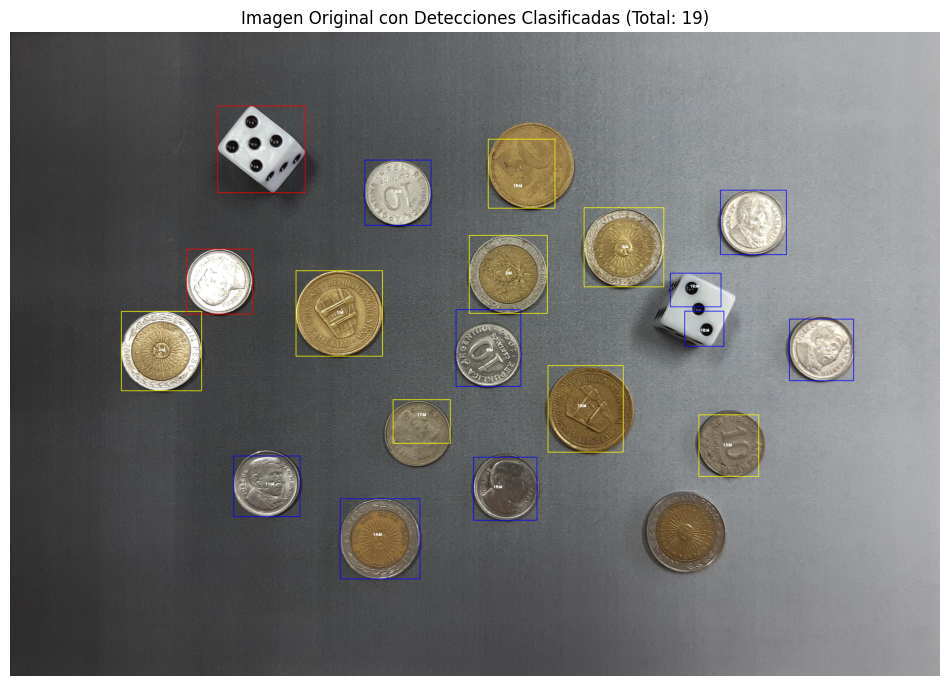

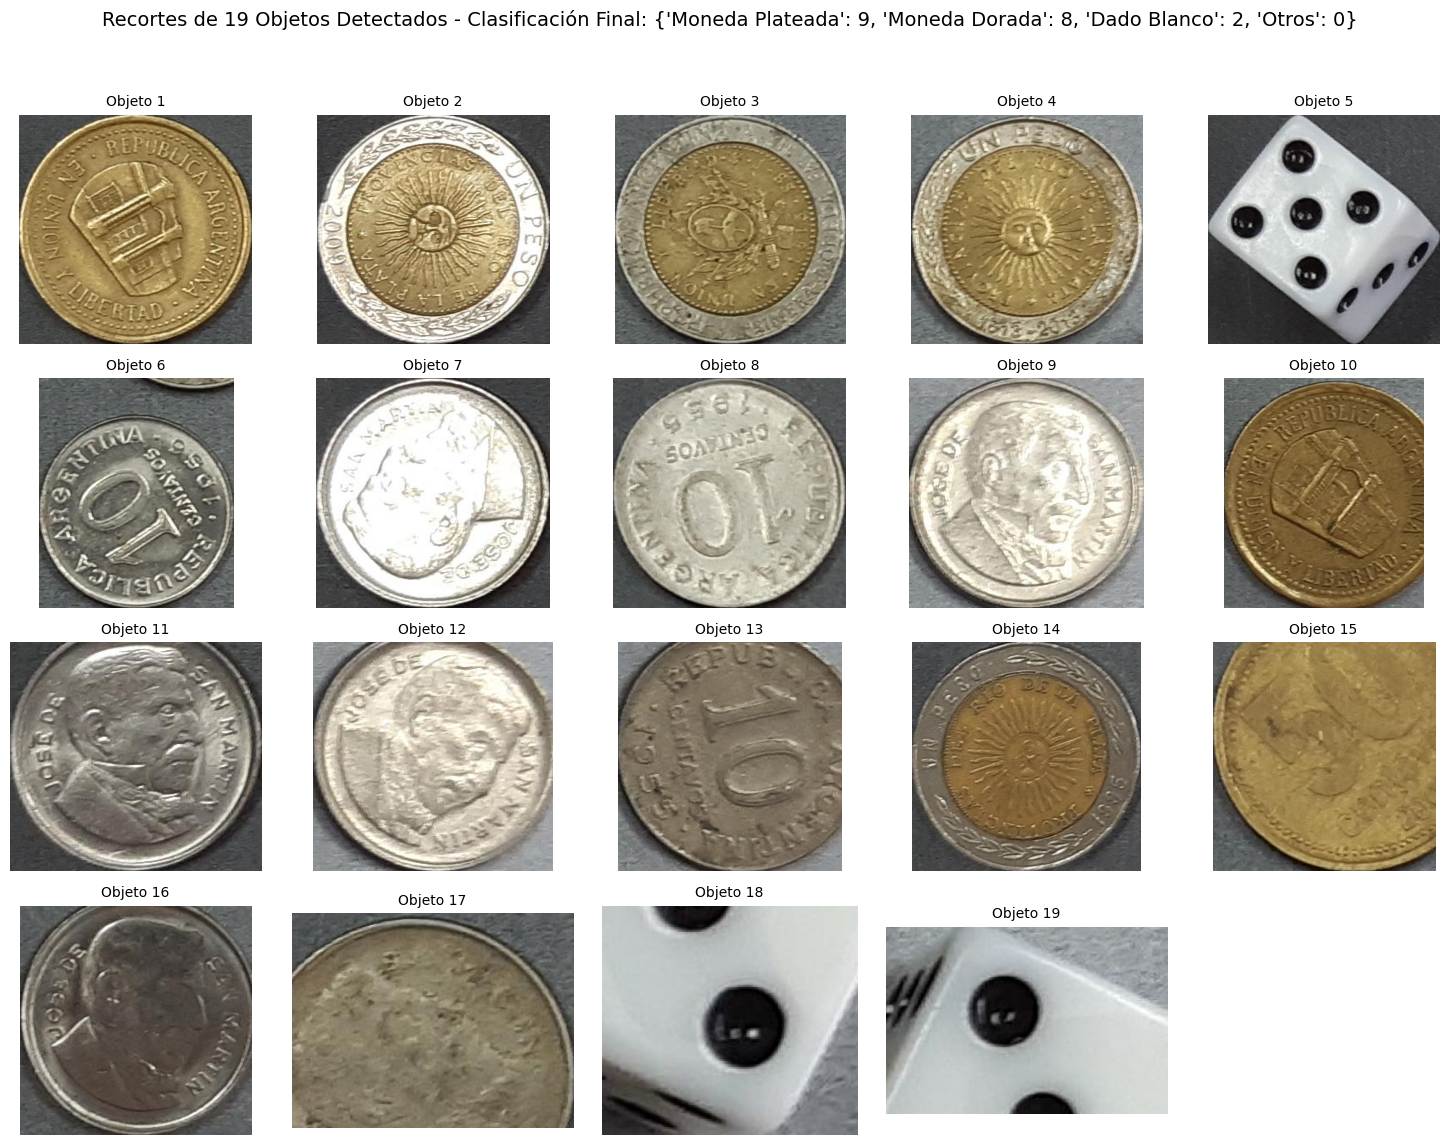

(19,
 {95900: 1,
  85400: 1,
  80400: 1,
  75100: 1,
  60900: 1,
  54100: 1,
  53500: 1,
  49400: 1,
  47400: 1,
  47000: 1,
  43000: 1,
  40800: 1,
  33100: 1,
  31900: 1,
  21600: 1,
  14300: 1,
  12700: 1,
  10600: 1,
  9900: 1},
 {'Moneda Plateada': 9, 'Moneda Dorada': 8, 'Dado Blanco': 2, 'Otros': 0},
 [array([[[84, 85, 87],
          [90, 91, 93],
          [76, 77, 79],
          ...,
          [75, 79, 80],
          [76, 80, 81],
          [77, 81, 82]],
  
         [[84, 85, 87],
          [90, 91, 93],
          [76, 77, 79],
          ...,
          [76, 80, 81],
          [77, 81, 82],
          [78, 82, 83]],
  
         [[78, 79, 81],
          [81, 82, 84],
          [73, 74, 76],
          ...,
          [77, 81, 82],
          [79, 83, 84],
          [79, 83, 84]],
  
         ...,
  
         [[68, 69, 71],
          [74, 75, 77],
          [75, 76, 78],
          ...,
          [80, 84, 85],
          [78, 82, 83],
          [74, 78, 79]],
  
         [[67, 68, 70],

In [ ]:

def encontrar_objetos_por_color(img, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, umbral_global, kernel, 
                                 LIMITE_SATURACION_DADO, LIMITE_SATURACION_MIN_DORADO, 
                                 LIMITE_HUE_MIN_DORADO, LIMITE_HUE_MAX_DORADO, num_dados_esperados):
    
    # 1. Preprocesamiento y Segmentación
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
    img_tophat = cv2.morphologyEx(img_gris, cv2.MORPH_TOPHAT, kernel_tophat)
    img_gris_blur = cv2.GaussianBlur(img_tophat, (3, 3), 0) 
    ret, img_umbralado = cv2.threshold(img_gris_blur, umbral_global, 255, cv2.THRESH_BINARY)
    kernel_cierre = np.ones((5, 5), np.uint8) 
    celda_cerrada = cv2.morphologyEx(img_umbralado, cv2.MORPH_CLOSE, kernel_cierre)
    kernel_apertura = np.ones((3, 3), np.uint8)
    celda_limpia = cv2.morphologyEx(celda_cerrada, cv2.MORPH_OPEN, kernel_apertura)
    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(celda_limpia, connectivity=8, ltype=cv2.CV_32S)
    
    objetos_validos = []
    
    # 2. Filtrado y agregando la máscara del objeto
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:
            mask_obj = (labels == i).astype(np.uint8) * 255 
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w_box = stats[i, cv2.CC_STAT_WIDTH]
            h_box = stats[i, cv2.CC_STAT_HEIGHT]
            relacion_aspecto = float(w_box) / h_box if h_box > 0 else 0.0

            objetos_validos.append({
                'id': i,
                'area': area,
                'stats': stats[i],
                'centroid': centroids[i],
                'relacion_aspecto': relacion_aspecto,
                'mask': mask_obj[y:y+h_box, x:x+w_box]
            })
            
    # --- 3. Clasificación Lógica por Color y Forma ---
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    candidatos_a_dados = [] 
    
    # ➡️ BUUCLE 1: Clasificación Preliminar y Búsqueda de Candidatos a Dados
    for objeto in objetos_validos: 
        
        x, y, w, h = objeto['stats'][cv2.CC_STAT_LEFT], objeto['stats'][cv2.CC_STAT_TOP], objeto['stats'][cv2.CC_STAT_WIDTH], objeto['stats'][cv2.CC_STAT_HEIGHT]
        hsv_recortado = img_hsv[y:y + h, x:x + w]
        mask_recortada = objeto['mask']
        h, s, v = cv2.mean(hsv_recortado, mask=mask_recortada)[:3] 
        
        if s < LIMITE_SATURACION_DADO:
            objeto['cuadratura'] = abs(objeto['relacion_aspecto'] - 1.0)
            candidatos_a_dados.append(objeto)
        
        if (s >= LIMITE_SATURACION_MIN_DORADO) and \
           (LIMITE_HUE_MIN_DORADO <= h <= LIMITE_HUE_MAX_DORADO):
            objeto['tipo_inicial'] = "Moneda Dorada"
            objeto['color_rectangulo_inicial'] = (0, 255, 255) # Amarillo
        else:
            objeto['tipo_inicial'] = "Moneda Plateada"
            objeto['color_rectangulo_inicial'] = (255, 0, 0) # Azul


    # ➡️ LÓGICA INTERMEDIA: Selección final de los 2 Dados más cuadrados
    ids_dados_finales = []
    if candidatos_a_dados:
        candidatos_a_dados.sort(key=lambda x: x['cuadratura'])
        dados_seleccionados = candidatos_a_dados[:num_dados_esperados]
        ids_dados_finales = [d['id'] for d in dados_seleccionados]


    # ➡️ BUUCLE 2: Clasificación Final, Conteo y Asignación de Color
    contador_tipos = {"Moneda Plateada": 0, "Moneda Dorada": 0, "Dado Blanco": 0, "Otros": 0} 
    
    for objeto in objetos_validos: 
        
        if objeto['id'] in ids_dados_finales:
            tipo_objeto = "Dado Blanco"
            color_rectangulo = (0, 0, 255) # Rojo (dado)
        else:
            tipo_objeto = objeto['tipo_inicial']
            color_rectangulo = objeto['color_rectangulo_inicial']

        objeto['tipo'] = tipo_objeto 
        objeto['color_rectangulo'] = color_rectangulo 
        contador_tipos[tipo_objeto] += 1

    
    # 4. Etiquetado y Dibujo de Resultados
    objetos_validos.sort(key=lambda x: x['area'], reverse=True)
    objetos_contados = 0
    recortes_para_ensamblar = []
    img_resultado = img.copy()
    contador_areas = {}

    for idx, objeto in enumerate(objetos_validos): 
        
        tipo_objeto = objeto['tipo']
        color_rectangulo = objeto['color_rectangulo']
        x, y, w, h = objeto['stats'][cv2.CC_STAT_LEFT], objeto['stats'][cv2.CC_STAT_TOP], objeto['stats'][cv2.CC_STAT_WIDTH], objeto['stats'][cv2.CC_STAT_HEIGHT]
        area = objeto['area']
        
        objetos_contados += 1 

        area_agrupada = int(math.ceil(area / 100.0)) * 100
        contador_areas[area_agrupada] = contador_areas.get(area_agrupada, 0) + 1
        
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), color_rectangulo, 2)
        (cX, cY) = objeto['centroid']
        etiqueta = f"{idx + 1}:{tipo_objeto[0]}" 
        cv2.putText(img_resultado, etiqueta,(int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        objeto_recortado = img[y:y + h, x:x + w]
        objeto_recortado_rgb = cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB)
        recortes_para_ensamblar.append(objeto_recortado_rgb)
    
    # --- 5. Resultados de la Consola ---
    print(f"Objetos detectados válidos: {objetos_contados}")
    print(f"Contador por tipo (final): {contador_tipos}")
    print(f"Contador por área agrupada: {contador_areas}")
    
    
    # ➡️ VISUALIZACIÓN 1: Imagen Original con Detecciones
    img_rgb_final = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb_final)
    plt.title(f"Imagen Original con Detecciones Clasificadas (Total: {objetos_contados})")
    plt.axis('off')
    plt.show() 

    # ➡️ VISUALIZACIÓN 2: Recortes de Objetos (Cuadrícula)
    N = len(recortes_para_ensamblar)
    cols = 5
    rows = (N + cols - 1) // cols

    plt.figure(figsize=(15, rows * 3))
    plt.suptitle(f"Recortes de {N} Objetos Detectados - Clasificación Final: {contador_tipos}", fontsize=14)

    for i, recorte in enumerate(recortes_para_ensamblar):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(recorte)
        plt.title(f"Objeto {i + 1}", fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show() 
    
    return objetos_contados, contador_areas, contador_tipos, recortes_para_ensamblar, img_resultado
        

encontrar_objetos_por_color(copia_img, 9000, 200000, 50, 75,10,55,15,40,2)


In [14]:

def encontrar_objetos_por_color(img, AREA_MINIMA_VALIDA, AREA_MAXIMA_VALIDA, umbral_global, kernel,  LIMITE_SATURACION_DADO,
    LIMITE_SATURACION_MIN_DORADO, LIMITE_HUE_MIN_DORADO, LIMITE_HUE_MAX_DORADO , num_dados_esperados ):
    
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
    img_tophat = cv2.morphologyEx(img_gris, cv2.MORPH_TOPHAT, kernel_tophat)
    img_gris_blur = cv2.GaussianBlur(img_tophat, (3, 3), 0) 
    ret, img_umbralado = cv2.threshold(img_gris_blur, umbral_global, 255, cv2.THRESH_BINARY)
    kernel_cierre = np.ones((5, 5), np.uint8) 
    celda_cerrada = cv2.morphologyEx(img_umbralado, cv2.MORPH_CLOSE, kernel_cierre)
    kernel_apertura = np.ones((3, 3), np.uint8)
    celda_limpia = cv2.morphologyEx(celda_cerrada, cv2.MORPH_OPEN, kernel_apertura)
    (num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(celda_limpia, connectivity=8, ltype=cv2.CV_32S)
    
    objetos_validos = []
    contador_areas = {}
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if AREA_MAXIMA_VALIDA > area >= AREA_MINIMA_VALIDA:
            
            mask_obj = (labels == i).astype(np.uint8) * 255 
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w_box = stats[i, cv2.CC_STAT_WIDTH]
            h_box = stats[i, cv2.CC_STAT_HEIGHT]
            relacion_aspecto = float(w_box) / h_box if h_box > 0 else 0.0

            objetos_validos.append({'id': i,'area': area,'stats': stats[i],'centroid': centroids[i],'relacion_aspecto': relacion_aspecto,'mask': mask_obj[y:y+h_box, x:x+w_box]})
        
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    candidatos_a_dados = []   

    for objeto in objetos_validos: 
        
        x, y, w, h = objeto['stats'][cv2.CC_STAT_LEFT], objeto['stats'][cv2.CC_STAT_TOP], objeto['stats'][cv2.CC_STAT_WIDTH], objeto['stats'][cv2.CC_STAT_HEIGHT]
        hsv_recortado = img_hsv[y:y + h, x:x + w]
        mask_recortada = objeto['mask']
        h, s, v = cv2.mean(hsv_recortado, mask=mask_recortada)[:3] 
        
        
        if s < LIMITE_SATURACION_DADO:
            objeto['cuadratura'] = abs(objeto['relacion_aspecto'] - 1.0)
            candidatos_a_dados.append(objeto)
        
        if (s >= LIMITE_SATURACION_MIN_DORADO) and \
           (LIMITE_HUE_MIN_DORADO <= h <= LIMITE_HUE_MAX_DORADO):
            objeto['tipo_inicial'] = "Moneda Dorada"
            objeto['color_rectangulo_inicial'] = (0, 255, 255)
        else:
            objeto['tipo_inicial'] = "Moneda Plateada"
            objeto['color_rectangulo_inicial'] = (255, 0, 0)


    
    ids_dados_finales = []
    if candidatos_a_dados:
        candidatos_a_dados.sort(key=lambda x: x['cuadratura'])
        dados_seleccionados = candidatos_a_dados[:num_dados_esperados]
        ids_dados_finales = [d['id'] for d in dados_seleccionados]


    contador_tipos = {"Moneda Plateada": 0, "Moneda Dorada": 0, "Dado Blanco": 0, "Otros": 0} 

    for objeto in objetos_validos: 
        
        if objeto['id'] in ids_dados_finales:
            tipo_objeto = "Dado Blanco"
            color_rectangulo = (0, 0, 255) # Rojo
        
        else:
            tipo_objeto = objeto['tipo_inicial']
            color_rectangulo = objeto['color_rectangulo_inicial']

        objeto['tipo'] = tipo_objeto 
        objeto['color_rectangulo'] = color_rectangulo 
        contador_tipos[tipo_objeto] += 1

    
    objetos_validos.sort(key=lambda x: x['area'], reverse=True)

    objetos_contados = 0
    recortes_para_ensamblar = []
    img_resultado = img.copy()

    for idx, objeto in enumerate(objetos_validos): 
        
        tipo_objeto = objeto['tipo']
        color_rectangulo = objeto['color_rectangulo']
        
        x = objeto['stats'][cv2.CC_STAT_LEFT]
        y = objeto['stats'][cv2.CC_STAT_TOP]
        w = objeto['stats'][cv2.CC_STAT_WIDTH]
        h = objeto['stats'][cv2.CC_STAT_HEIGHT]
        area = objeto['area']
        
        objetos_contados += 1 

        area_agrupada = int(math.ceil(area / 100.0)) * 100
        contador_areas[area_agrupada] = contador_areas.get(area_agrupada, 0) + 1
        
        cv2.rectangle(img_resultado, (x, y), (x + w, y + h), color_rectangulo, 2)
        (cX, cY) = objeto['centroid']
        etiqueta = f"{idx + 1}:{tipo_objeto[0]}" 
        cv2.putText(img_resultado, etiqueta,(int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        objeto_recortado = img[y:y + h, x:x + w]
        objeto_recortado_rgb = cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB)
        recortes_para_ensamblar.append(objeto_recortado_rgb)
    
    print(f"Objetos detectados válidos: {objetos_contados}")
    print(f"Contador por tipo: {contador_tipos}")
    print(f"Contador por área agrupada: {contador_areas}")
    

    return objetos_contados, contador_areas, contador_tipos, recortes_para_ensamblar, img_resultado

encontrar_objetos_por_color(copia_img, 9000, 200000, 50, 75,10,55,15,40,2)

Objetos detectados válidos: 19
Contador por tipo: {'Moneda Plateada': 9, 'Moneda Dorada': 8, 'Dado Blanco': 2, 'Otros': 0}
Contador por área agrupada: {95900: 1, 85400: 1, 80400: 1, 75100: 1, 60900: 1, 54100: 1, 53500: 1, 49400: 1, 47400: 1, 47000: 1, 43000: 1, 40800: 1, 33100: 1, 31900: 1, 21600: 1, 14300: 1, 12700: 1, 10600: 1, 9900: 1}


(19,
 {95900: 1,
  85400: 1,
  80400: 1,
  75100: 1,
  60900: 1,
  54100: 1,
  53500: 1,
  49400: 1,
  47400: 1,
  47000: 1,
  43000: 1,
  40800: 1,
  33100: 1,
  31900: 1,
  21600: 1,
  14300: 1,
  12700: 1,
  10600: 1,
  9900: 1},
 {'Moneda Plateada': 9, 'Moneda Dorada': 8, 'Dado Blanco': 2, 'Otros': 0},
 [array([[[84, 85, 87],
          [90, 91, 93],
          [76, 77, 79],
          ...,
          [75, 79, 80],
          [76, 80, 81],
          [77, 81, 82]],
  
         [[84, 85, 87],
          [90, 91, 93],
          [76, 77, 79],
          ...,
          [76, 80, 81],
          [77, 81, 82],
          [78, 82, 83]],
  
         [[78, 79, 81],
          [81, 82, 84],
          [73, 74, 76],
          ...,
          [77, 81, 82],
          [79, 83, 84],
          [79, 83, 84]],
  
         ...,
  
         [[68, 69, 71],
          [74, 75, 77],
          [75, 76, 78],
          ...,
          [80, 84, 85],
          [78, 82, 83],
          [74, 78, 79]],
  
         [[67, 68, 70],